# Random Walk vs PageRank: Parameter Comparison

This notebook compares how the random walk algorithm's accuracy (vs PageRank baseline) varies with:
1. **packets_per_node** — number of packets spawned at each node
2. **TTL (rounds)** — how many hops packets live in the random walk

In [1]:
import networkx as nx
import numpy as np
import random
from matplotlib import pyplot as plt
from collections import defaultdict
from tqdm import tqdm
from scipy.stats import spearmanr, kendalltau

## 1. Graph Generation (same as grahgen.ipynb)

In [2]:
rng = np.random.default_rng(42)

N = 1000
communities = 10
sizes = [N // communities] * communities
p_in, p_out = 0.06, 0.002

probs = np.full((communities, communities), p_out)
np.fill_diagonal(probs, p_in)
G_base = nx.stochastic_block_model(sizes, probs, seed=42, directed=False)

G = nx.DiGraph()
G.add_nodes_from(G_base.nodes(data=True))
alpha0, beta0 = 2.0, 5.0
for u, v in G_base.edges():
    if rng.random() < 0.7:
        G.add_edge(u, v, w=float(rng.beta(alpha0, beta0)))
    if rng.random() < 0.7:
        G.add_edge(v, u, w=float(rng.beta(alpha0, beta0)))

for node in G.nodes():
    G.nodes[node]['interest'] = rng.integers(0, 10)
    G.nodes[node]['seniority'] = rng.normal(0, 1)

In [3]:
def homophily(u, v, lam=0.8):
    iu = G.nodes[u]['interest']; iv = G.nodes[v]['interest']
    su = G.nodes[u]['seniority']; sv = G.nodes[v]['seniority']
    d = abs(iu - iv) + 0.5 * abs(su - sv)
    return np.exp(-lam * d)

def pref_attach(v, eps=1.0, alpha=0.7):
    return (G.in_degree(v) + eps) ** alpha

def reciprocity_score(u, v, rho=0.5):
    return rho if G.has_edge(v, u) else 0.0

def triadic_closure(u, v, theta=1.0):
    best = 0.0
    for k in G.successors(u):
        if G.has_edge(k, v):
            best = max(best, G[u][k]['w'] * G[k][v]['w'])
    return theta * best

def capacity_factor(u, dstar=80, kappa=0.08):
    return 1.0 / (1.0 + np.exp(kappa * (G.out_degree(u) - dstar)))

def form_prob(u, v, a=0.4, b=0.3, c=0.2, r=0.1):
    score = (a * homophily(u, v) +
             b * pref_attach(v) +
             c * triadic_closure(u, v) +
             r * reciprocity_score(u, v))
    return np.tanh(score) * capacity_factor(u)

def reinforce(w, eta_pos=0.25):
    return w + eta_pos * (1.0 - w)

def penalize(w, eta_neg=0.5):
    return w - eta_neg * w

def decay(w, gamma=0.01):
    return w * np.exp(-gamma)

In [4]:
T = 50
tau = 0.05
beta_prop = 0.4
p_interact = 0.05

for t in tqdm(range(T)):
    candidates = []
    nodes = list(G.nodes())
    for _ in range(N // 2):
        u = int(rng.integers(0, N))
        weights = []
        for v in nodes:
            if v == u:
                weights.append(0.0)
            else:
                weights.append(0.6 * homophily(u, v) + 0.4 * pref_attach(v))
        v = int(rng.choice(nodes, p=np.array(weights)/np.sum(weights)))
        candidates.append((u, v))

    for u, v in candidates:
        if not G.has_edge(u, v):
            p = form_prob(u, v)
            if rng.random() < min(1.0, p):
                G.add_edge(u, v, w=float(rng.beta(2, 8)))
        else:
            if rng.random() < p_interact:
                success = rng.random() < 0.8
                w = G[u][v]['w']
                w = reinforce(w) if success else penalize(w)
                G[u][v]['w'] = float(np.clip(w, 0.0, 1.0))

    for u, v, data in list(G.edges(data=True)):
        G[u][v]['w'] = float(decay(data['w']))
        if G[u][v]['w'] < tau:
            G.remove_edge(u, v)

    to_set = []
    to_add = []
    for u in nodes:
        succ_u = list(G.successors(u))
        for k in succ_u:
            wk = G[u][k]['w']
            if wk < 0.2:
                continue
            succ_k = list(G.successors(k))
            for v in succ_k:
                if u == v:
                    continue
                wkv = G[k][v]['w']
                propagated = beta_prop * wk * wkv
                if propagated <= tau:
                    continue
                if G.has_edge(u, v):
                    if propagated > G[u][v]['w']:
                        to_set.append((u, v, float(propagated)))
                else:
                    if rng.random() < capacity_factor(u):
                        to_add.append((u, v, float(propagated)))
    for u, v, w in to_set:
        if w > G[u][v]['w']:
            G[u][v]['w'] = w
    for u, v, w in to_add:
        if G.has_edge(u, v):
            if w > G[u][v]['w']:
                G[u][v]['w'] = w
        else:
            G.add_edge(u, v, w=w)

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())
print("Average out-degree:", round(np.mean([G.out_degree(n) for n in G.nodes()]), 2))
print("Reciprocity:", round(nx.reciprocity(G) or 0.0, 3))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:18<00:00,  1.56s/it]

Nodes: 1000 Edges: 37414
Average out-degree: 37.41
Reciprocity: 0.12


## 2. PageRank Baseline

In [5]:
pagerank = nx.pagerank(G, weight='w', alpha=1.0)
pr_array = np.array([pagerank[n] for n in sorted(G.nodes())])
print("PageRank computed. Sum:", pr_array.sum())

PageRank computed. Sum: 1.0


## 3. Random Walk Simulation

In [6]:
def run_simulation(G, packets_per_node=50, rounds=10):
    """Random walk: each node starts with packets_per_node packets,
    each packet hops for `rounds` steps following weighted edges."""
    packets_in = {}
    packets_out = defaultdict(int)
    for n in G.nodes:
        packets_in[n] = packets_per_node
    for epoch in range(rounds):
        for n in G.nodes:
            neighbours = list(G.successors(n))
            if not neighbours:
                continue
            weights = [G.edges[(n, neigh)]["w"] for neigh in neighbours]
            for inp in range(packets_in.get(n, 0)):
                next_hop = random.choices(neighbours, weights=weights, k=1)[0]
                packets_out[next_hop] += 1
        packets_in = packets_out
        packets_out = defaultdict(int)
    return packets_in

def compute_error_metrics(G, packets_per_node, rounds, pr_array, num_trials=3):
    """Run simulation multiple times and compute many error metrics vs pagerank."""
    results = defaultdict(list)
    sorted_nodes = sorted(G.nodes())
    
    for trial in range(num_trials):
        final_pkt = run_simulation(G, packets_per_node=packets_per_node, rounds=rounds)
        total = sum(final_pkt.values())
        if total == 0:
            continue
        walk_array = np.array([final_pkt.get(n, 0) / total for n in sorted_nodes])
        
        diff = walk_array - pr_array
        abs_diff = np.abs(diff)
        
        # --- Absolute error metrics (L-N norms) ---
        results['l1'].append(np.mean(abs_diff))
        results['l2'].append(np.sqrt(np.mean(diff**2)))
        results['l3'].append(np.mean(abs_diff**3) ** (1.0/3.0))
        results['l5'].append(np.mean(abs_diff**5) ** (1.0/5.0))
        results['linf'].append(np.max(abs_diff))
        
        # --- Rank correlation ---
        sp, _ = spearmanr(walk_array, pr_array)
        kt, _ = kendalltau(walk_array, pr_array)
        results['spearman'].append(sp)
        results['kendall'].append(kt)
        
        # --- Ratio-based metrics ---
        pr_safe = np.clip(pr_array, 1e-15, None)
        walk_safe = np.clip(walk_array, 1e-15, None)
        ratios = walk_safe / pr_safe
        log_ratios = np.log(ratios)
        
        results['log_ratio_std'].append(np.std(log_ratios))
        results['log_ratio_mae'].append(np.mean(np.abs(log_ratios)))
        
        # Fraction of nodes outside various bands
        results['frac_outside_5pct'].append(np.mean((ratios < 0.95) | (ratios > 1.05)))
        results['frac_outside_10pct'].append(np.mean((ratios < 0.9) | (ratios > 1.1)))
        results['frac_outside_15pct'].append(np.mean((ratios < 0.85) | (ratios > 1.15)))
        results['frac_outside_20pct'].append(np.mean((ratios < 0.8) | (ratios > 1.2)))
        
        # --- Relative error metrics ---
        results['mean_relative_error'].append(np.mean(abs_diff / pr_safe))
        
        # Chi-squared statistic
        results['chi_squared'].append(np.sum(diff**2 / pr_safe))
        
        # --- Distributional distances ---
        kl = np.sum(pr_safe * np.log(pr_safe / walk_safe))
        results['kl_divergence'].append(kl)
        
        results['total_variation'].append(0.5 * np.sum(abs_diff))
        
        # --- Top-k overlap ---
        for k in [50, 100]:
            top_pr = set(np.argsort(pr_array)[-k:])
            top_walk = set(np.argsort(walk_array)[-k:])
            jaccard = len(top_pr & top_walk) / len(top_pr | top_walk)
            results[f'top{k}_jaccard'].append(jaccard)
    
    # Aggregate: mean and std for each metric
    out = {}
    for key, vals in results.items():
        out[f'{key}_mean'] = np.mean(vals)
        out[f'{key}_std'] = np.std(vals)
    return out

## 4. Parameter Sweep

In [7]:
packets_values = [1, 5, 10, 25, 50, 100, 250]
ttl_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 20, 30]
num_trials = 10

# Sweep over TTL with fixed packets_per_node=100
print("=== Sweeping TTL (packets_per_node=100) ===")
results_ttl = []
for ttl in tqdm(ttl_values):
    metrics = compute_error_metrics(G, packets_per_node=100, rounds=ttl, pr_array=pr_array, num_trials=num_trials)
    metrics['ttl'] = ttl
    results_ttl.append(metrics)

# Sweep over packets_per_node with fixed TTL=5
print("\n=== Sweeping packets_per_node (TTL=5) ===")
results_packets = []
for pkt in tqdm(packets_values):
    metrics = compute_error_metrics(G, packets_per_node=pkt, rounds=5, pr_array=pr_array, num_trials=num_trials)
    metrics['packets'] = pkt
    results_packets.append(metrics)

=== Sweeping TTL (packets_per_node=100) ===


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [03:49<00:00, 15.31s/it]



=== Sweeping packets_per_node (TTL=5) ===


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:36<00:00,  5.18s/it]


## 5. Results: TTL Sweep (fixed packets_per_node=100)

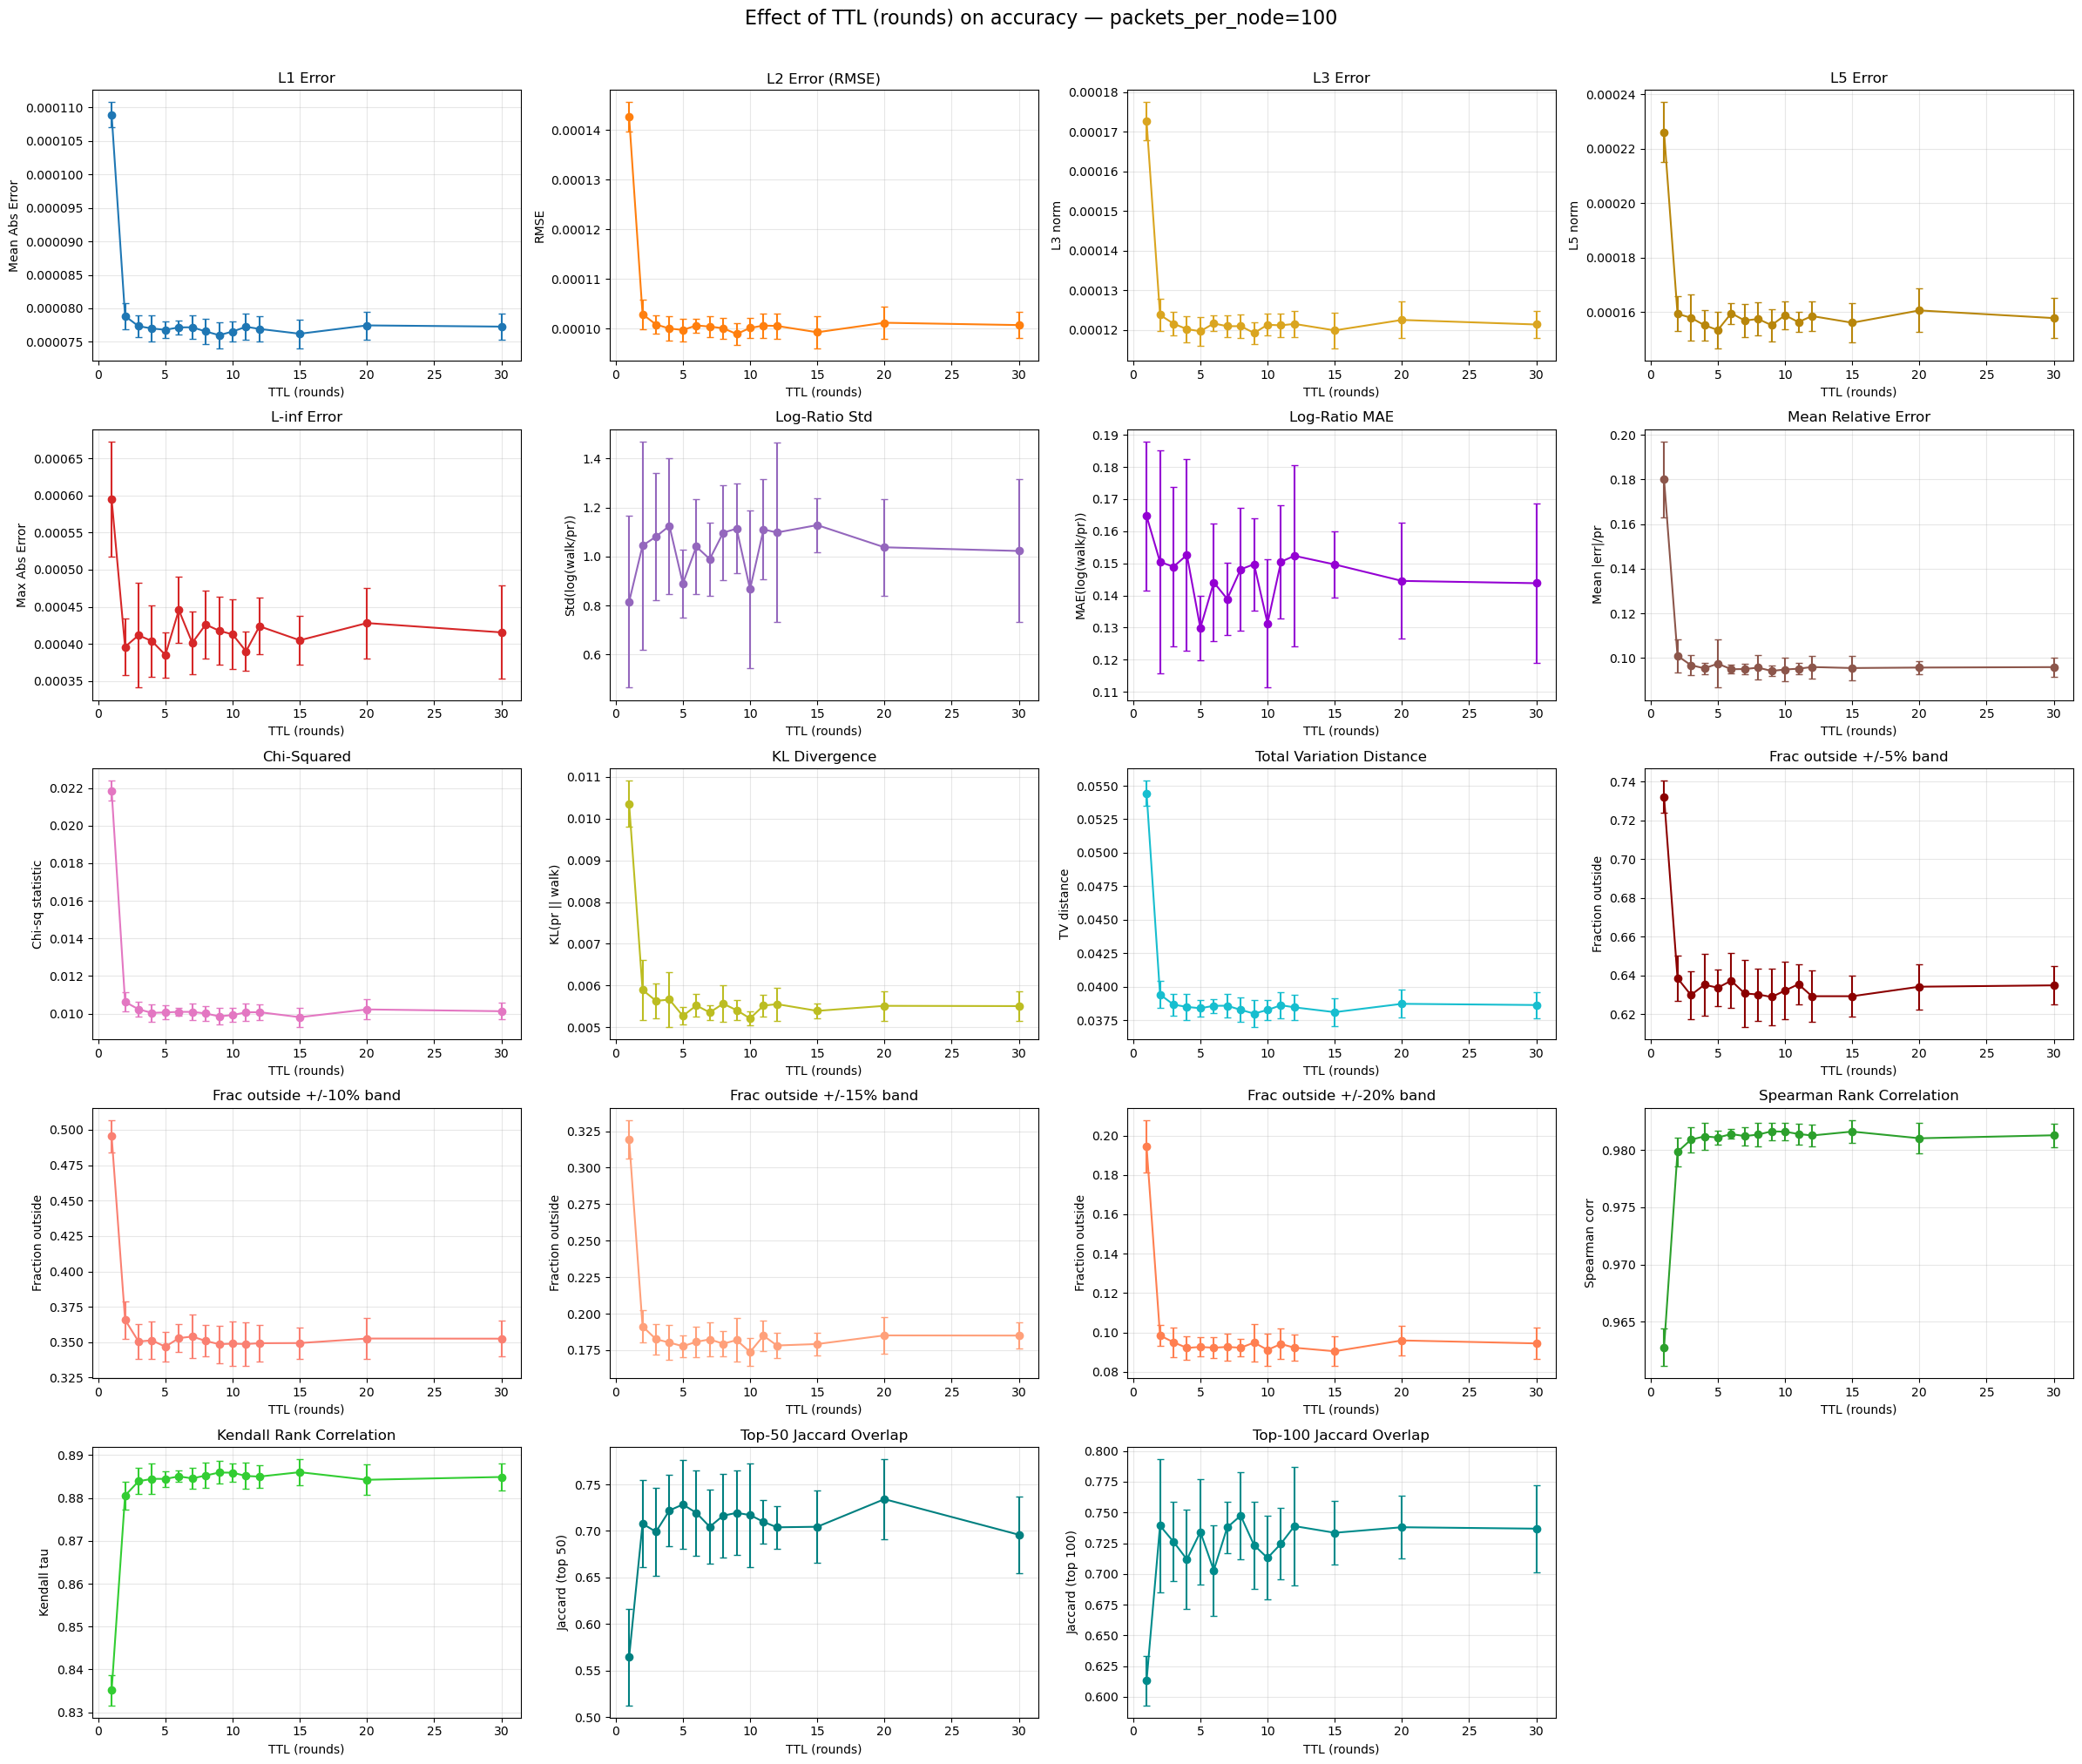

In [8]:
metric_configs = [
    # (key_prefix, ylabel, title, color, higher_is_better)
    ('l1',                 'Mean Abs Error',         'L1 Error',                    'tab:blue',    False),
    ('l2',                 'RMSE',                   'L2 Error (RMSE)',             'tab:orange',  False),
    ('l3',                 'L3 norm',                'L3 Error',                    'goldenrod',   False),
    ('l5',                 'L5 norm',                'L5 Error',                    'darkgoldenrod', False),
    ('linf',               'Max Abs Error',          'L-inf Error',                 'tab:red',     False),
    ('log_ratio_std',      'Std(log(walk/pr))',      'Log-Ratio Std',               'tab:purple',  False),
    ('log_ratio_mae',      'MAE(log(walk/pr))',      'Log-Ratio MAE',               'darkviolet',  False),
    ('mean_relative_error','Mean |err|/pr',          'Mean Relative Error',         'tab:brown',   False),
    ('chi_squared',        'Chi-sq statistic',       'Chi-Squared',                 'tab:pink',    False),
    ('kl_divergence',      'KL(pr || walk)',         'KL Divergence',               'tab:olive',   False),
    ('total_variation',    'TV distance',            'Total Variation Distance',    'tab:cyan',    False),
    ('frac_outside_5pct',  'Fraction outside',       'Frac outside +/-5% band',     'darkred',     False),
    ('frac_outside_10pct', 'Fraction outside',       'Frac outside +/-10% band',    'salmon',      False),
    ('frac_outside_15pct', 'Fraction outside',       'Frac outside +/-15% band',    'lightsalmon', False),
    ('frac_outside_20pct', 'Fraction outside',       'Frac outside +/-20% band',    'coral',       False),
    ('spearman',           'Spearman corr',          'Spearman Rank Correlation',   'tab:green',   True),
    ('kendall',            'Kendall tau',            'Kendall Rank Correlation',    'limegreen',   True),
    ('top50_jaccard',      'Jaccard (top 50)',       'Top-50 Jaccard Overlap',      'teal',        True),
    ('top100_jaccard',     'Jaccard (top 100)',      'Top-100 Jaccard Overlap',     'darkcyan',    True),
]

n_metrics = len(metric_configs)
ncols = 4
nrows = (n_metrics + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
fig.suptitle('Effect of TTL (rounds) on accuracy — packets_per_node=100', fontsize=16, y=1.01)
axes_flat = axes.flatten()

ttls = [r['ttl'] for r in results_ttl]

for idx, (key, ylabel, title, color, _) in enumerate(metric_configs):
    ax = axes_flat[idx]
    means = [r[f'{key}_mean'] for r in results_ttl]
    stds = [r[f'{key}_std'] for r in results_ttl]
    ax.errorbar(ttls, means, yerr=stds, marker='o', capsize=3, color=color, linewidth=1.5)
    ax.set_xlabel('TTL (rounds)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

# Hide unused axes
for idx in range(n_metrics, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Results: Packets Sweep (fixed TTL=5)

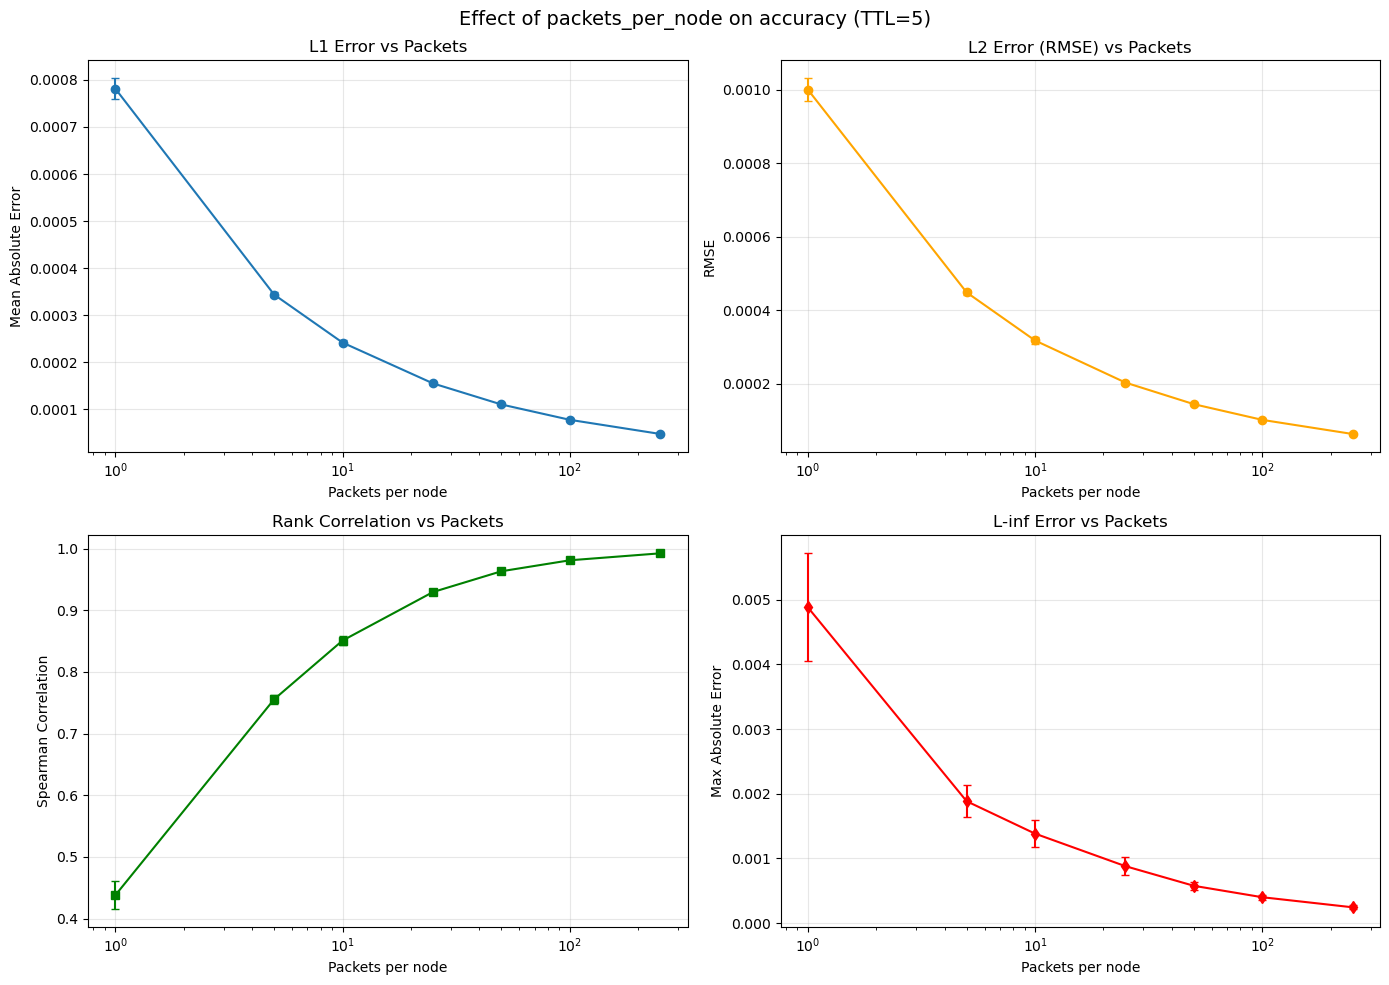

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Effect of packets_per_node on accuracy (TTL=5)', fontsize=14)

pkts = [r['packets'] for r in results_packets]

# L1 error
ax = axes[0, 0]
means = [r['l1_mean'] for r in results_packets]
stds = [r['l1_std'] for r in results_packets]
ax.errorbar(pkts, means, yerr=stds, marker='o', capsize=3)
ax.set_xlabel('Packets per node')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('L1 Error vs Packets')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# L2 error
ax = axes[0, 1]
means = [r['l2_mean'] for r in results_packets]
stds = [r['l2_std'] for r in results_packets]
ax.errorbar(pkts, means, yerr=stds, marker='o', capsize=3, color='orange')
ax.set_xlabel('Packets per node')
ax.set_ylabel('RMSE')
ax.set_title('L2 Error (RMSE) vs Packets')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Spearman correlation
ax = axes[1, 0]
means = [r['spearman_mean'] for r in results_packets]
stds = [r['spearman_std'] for r in results_packets]
ax.errorbar(pkts, means, yerr=stds, marker='s', capsize=3, color='green')
ax.set_xlabel('Packets per node')
ax.set_ylabel('Spearman Correlation')
ax.set_title('Rank Correlation vs Packets')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# L-inf error
ax = axes[1, 1]
means = [r['linf_mean'] for r in results_packets]
stds = [r['linf_std'] for r in results_packets]
ax.errorbar(pkts, means, yerr=stds, marker='d', capsize=3, color='red')
ax.set_xlabel('Packets per node')
ax.set_ylabel('Max Absolute Error')
ax.set_title('L-inf Error vs Packets')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 2D Heatmap: Joint Effect of TTL and Packets

In [10]:
# Coarser grid for the joint sweep (full grid is expensive)
packets_grid = [1, 5, 10, 25, 50, 100, 250]
ttl_grid = [1, 2, 3, 5, 8, 10, 15, 20]

l1_matrix = np.zeros((len(ttl_grid), len(packets_grid)))
spearman_matrix = np.zeros((len(ttl_grid), len(packets_grid)))

total = len(ttl_grid) * len(packets_grid)
with tqdm(total=total) as pbar:
    for i, ttl in enumerate(ttl_grid):
        for j, pkt in enumerate(packets_grid):
            metrics = compute_error_metrics(G, packets_per_node=pkt, rounds=ttl, pr_array=pr_array, num_trials=3)
            l1_matrix[i, j] = metrics['l1_mean']
            spearman_matrix[i, j] = metrics['spearman_mean']
            pbar.update(1)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 56/56 [02:27<00:00,  2.64s/it]


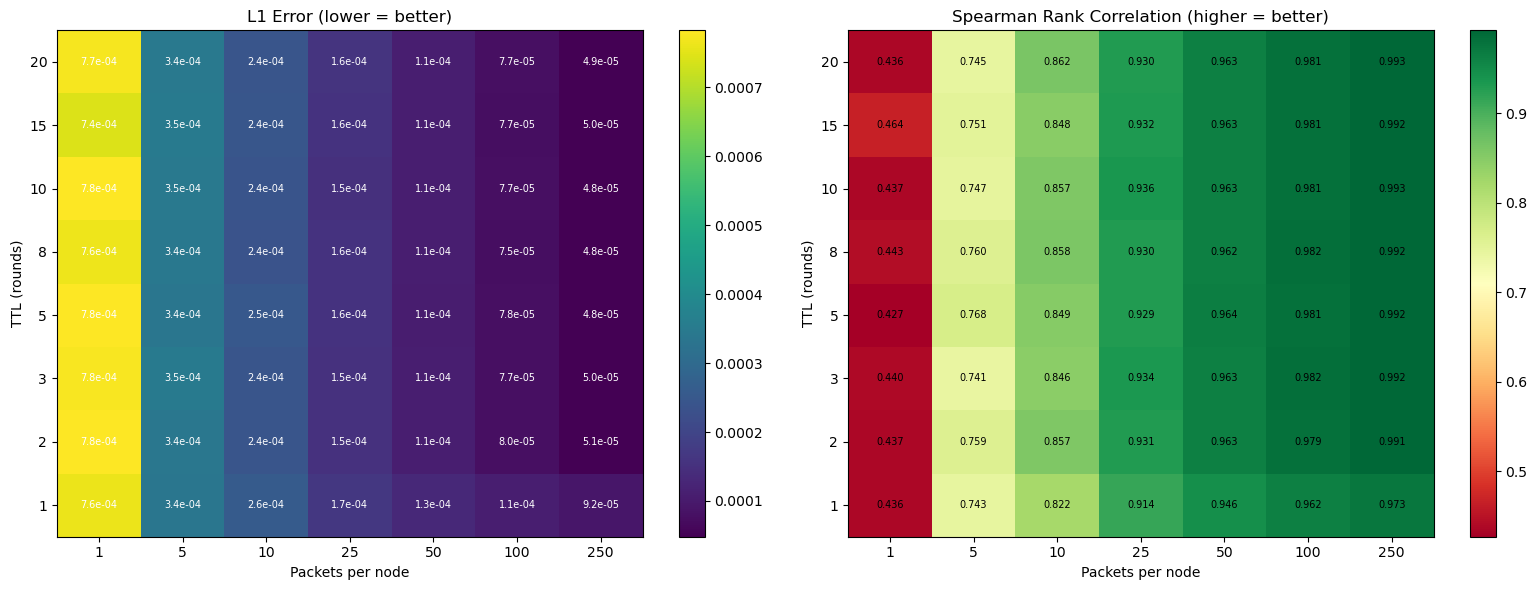

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# L1 heatmap
ax = axes[0]
im = ax.imshow(l1_matrix, aspect='auto', origin='lower')
ax.set_xticks(range(len(packets_grid)))
ax.set_xticklabels(packets_grid)
ax.set_yticks(range(len(ttl_grid)))
ax.set_yticklabels(ttl_grid)
ax.set_xlabel('Packets per node')
ax.set_ylabel('TTL (rounds)')
ax.set_title('L1 Error (lower = better)')
plt.colorbar(im, ax=ax)
# Annotate cells
for i in range(len(ttl_grid)):
    for j in range(len(packets_grid)):
        ax.text(j, i, f'{l1_matrix[i,j]:.1e}', ha='center', va='center', fontsize=7, color='white')

# Spearman heatmap
ax = axes[1]
im = ax.imshow(spearman_matrix, aspect='auto', origin='lower', cmap='RdYlGn')
ax.set_xticks(range(len(packets_grid)))
ax.set_xticklabels(packets_grid)
ax.set_yticks(range(len(ttl_grid)))
ax.set_yticklabels(ttl_grid)
ax.set_xlabel('Packets per node')
ax.set_ylabel('TTL (rounds)')
ax.set_title('Spearman Rank Correlation (higher = better)')
plt.colorbar(im, ax=ax)
for i in range(len(ttl_grid)):
    for j in range(len(packets_grid)):
        ax.text(j, i, f'{spearman_matrix[i,j]:.3f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()

## 8. Total Packets Budget: Error vs Compute

For a fixed total budget of packets (packets_per_node * N), how should we split between more packets vs more rounds?

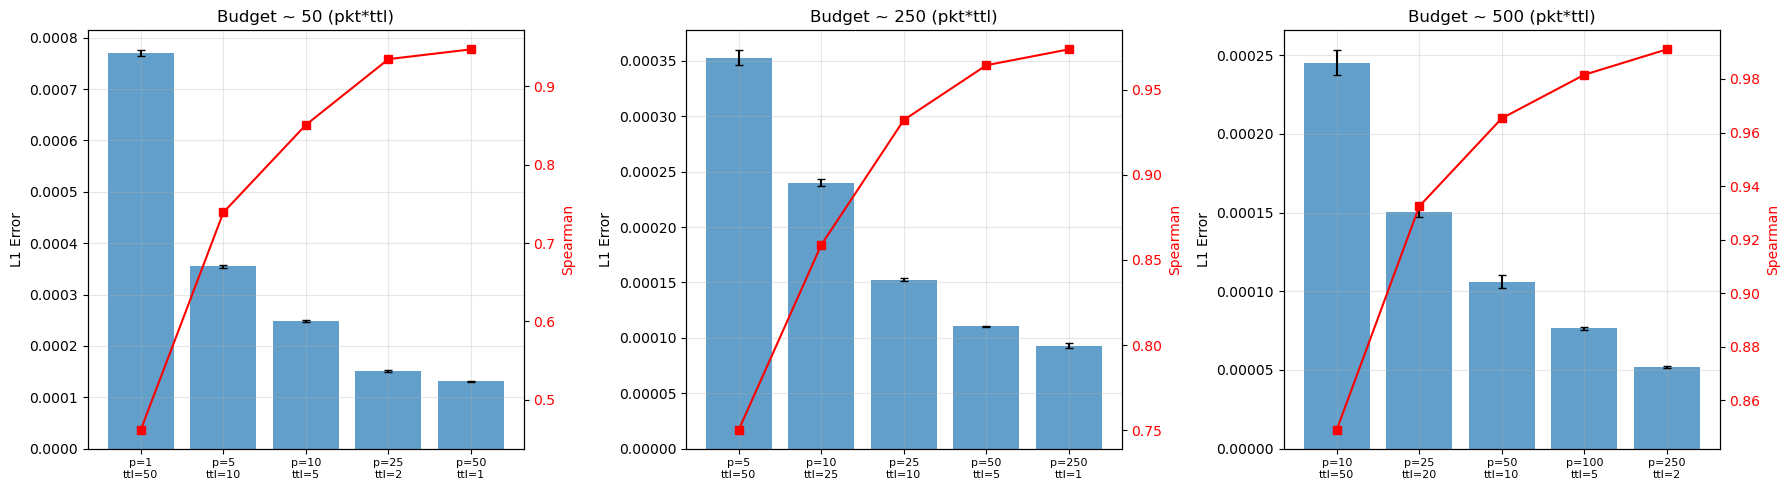

In [12]:
# Fixed total budget = packets_per_node * rounds (proxy for total compute)
# We compare different (packets, ttl) combos that have similar total work
budgets = {
    50:   [(1, 50), (5, 10), (10, 5), (25, 2), (50, 1)],
    250:  [(5, 50), (10, 25), (25, 10), (50, 5), (250, 1)],
    500:  [(10, 50), (25, 20), (50, 10), (100, 5), (250, 2)],
}

fig, axes = plt.subplots(1, len(budgets), figsize=(6*len(budgets), 5))

for idx, (budget, combos) in enumerate(budgets.items()):
    ax = axes[idx]
    labels = []
    l1_means = []
    l1_stds = []
    sp_means = []
    
    for pkt, ttl in combos:
        metrics = compute_error_metrics(G, packets_per_node=pkt, rounds=ttl, pr_array=pr_array, num_trials=3)
        labels.append(f'p={pkt}\nttl={ttl}')
        l1_means.append(metrics['l1_mean'])
        l1_stds.append(metrics['l1_std'])
        sp_means.append(metrics['spearman_mean'])
    
    x = range(len(labels))
    ax.bar(x, l1_means, yerr=l1_stds, capsize=3, alpha=0.7, label='L1 error')
    ax2 = ax.twinx()
    ax2.plot(x, sp_means, 'rs-', label='Spearman corr')
    ax2.set_ylabel('Spearman', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('L1 Error')
    ax.set_title(f'Budget ~ {budget} (pkt*ttl)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Distribution Comparison for Selected Configs

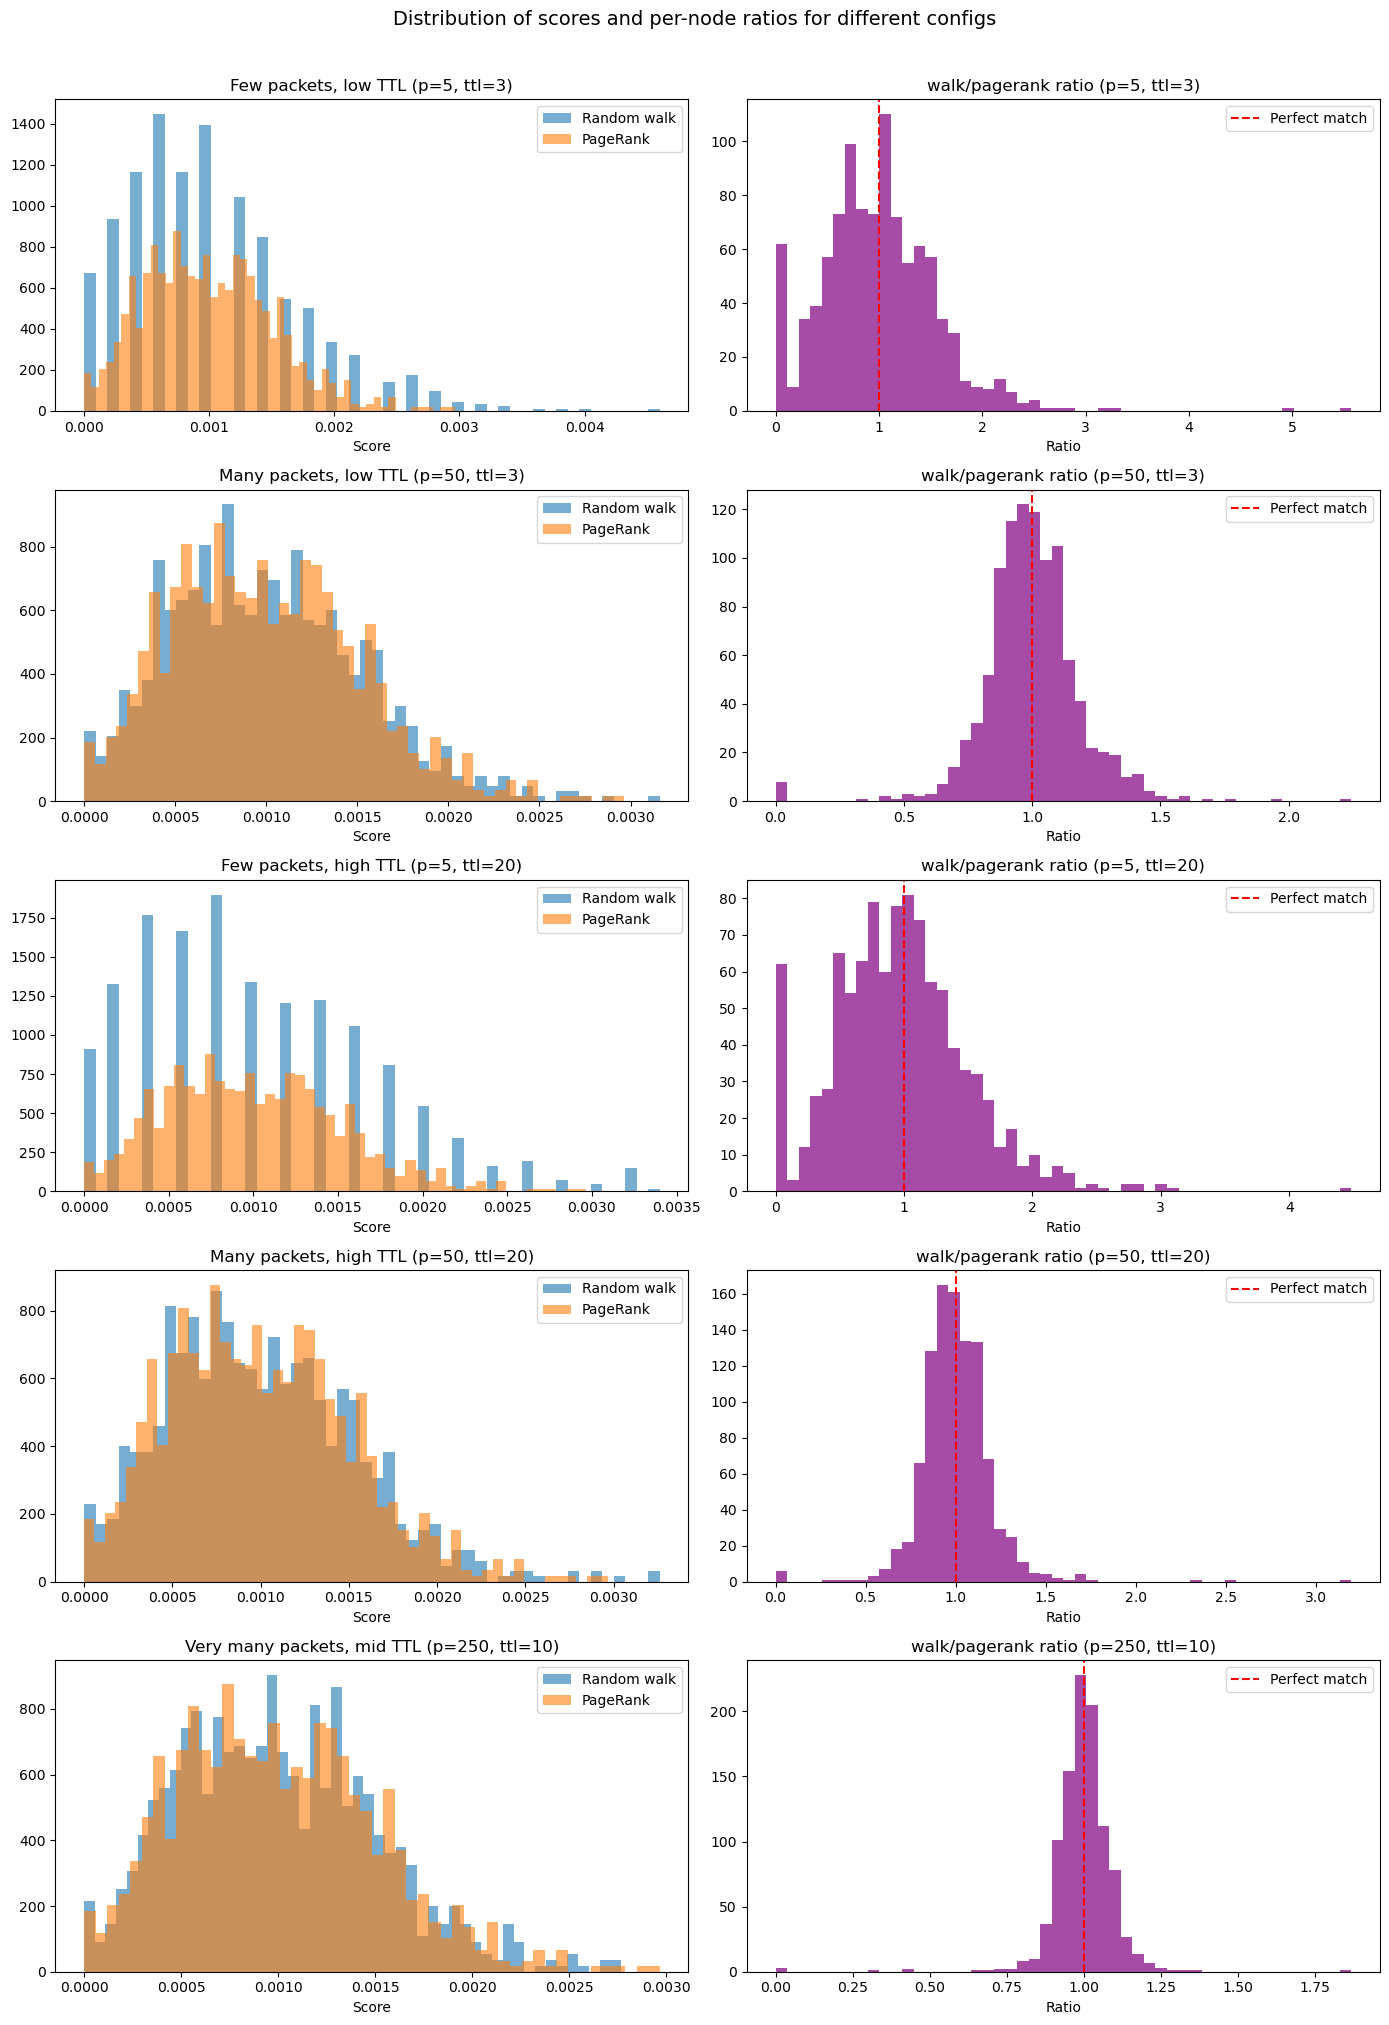

In [13]:
configs = [
    (5, 3, 'Few packets, low TTL'),
    (50, 3, 'Many packets, low TTL'),
    (5, 20, 'Few packets, high TTL'),
    (50, 20, 'Many packets, high TTL'),
    (250, 10, 'Very many packets, mid TTL'),
]

sorted_nodes = sorted(G.nodes())

fig, axes = plt.subplots(len(configs), 2, figsize=(14, 4*len(configs)))
fig.suptitle('Distribution of scores and per-node ratios for different configs', fontsize=14, y=1.01)

for i, (pkt, ttl, label) in enumerate(configs):
    final_pkt = run_simulation(G, packets_per_node=pkt, rounds=ttl)
    total = sum(final_pkt.values())
    walk_array = np.array([final_pkt.get(n, 0) / total for n in sorted_nodes])
    
    # Left: overlaid histograms
    ax = axes[i, 0]
    ax.hist(walk_array, bins=50, alpha=0.6, label='Random walk', density=True)
    ax.hist(pr_array, bins=50, alpha=0.6, label='PageRank', density=True)
    ax.set_title(f'{label} (p={pkt}, ttl={ttl})')
    ax.set_xlabel('Score')
    ax.legend()
    
    # Right: ratio histogram
    ax = axes[i, 1]
    ratios = walk_array / np.clip(pr_array, 1e-12, None)
    ax.hist(ratios, bins=50, alpha=0.7, color='purple')
    ax.axvline(1.0, color='red', linestyle='--', label='Perfect match')
    ax.set_title(f'walk/pagerank ratio (p={pkt}, ttl={ttl})')
    ax.set_xlabel('Ratio')
    ax.legend()

plt.tight_layout()
plt.show()